In [1]:
import numpy as np
from Perceptron import Perceptron
model = Perceptron(input_size=7)  

In [2]:
# ── 2. DATA ────────────────────────────────────────────────────────

X = np.array([
    [9, 8],   # study hrs, sleep hrs
    [8, 7],
    [7, 8],
    [6, 6],
    [5, 7],
    [4, 5],
    [3, 4],
    [2, 6],
    [1, 3],
    [2, 4],
], dtype=float)

Y = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0], dtype=float)




In [3]:
# ── 3. TRAIN / TEST SPLIT (manual, no sklearn!) ────────────────────

X_train = X[:7]    # first 7 students for training
X_test  = X[3:]    # last 3 students for testing

Y_train = Y[:7]
Y_test  = Y[3:]




In [4]:
# ── 4. FEATURE SCALING (manual, no sklearn!) ──────────────────────

mean = X_train.mean(axis=0)   # mean of each feature
std  = X_train.std(axis=0)    # std of each feature

X_train_scaled = (X_train - mean) / std
X_test_scaled  = (X_test  - mean) / std   # use SAME mean and std!




In [5]:
# ── 5. CREATE + TRAIN MODEL ────────────────────────────────────────

np.random.seed(42)   # so we get same random weights every run
model = Perceptron(input_size=2)

model.fit(
    inputs        = X_train_scaled,
    targets       = Y_train,
    learning_rate = 0.1,
    num_epochs    = 100
)




Epoch 1/100  |  Loss: 0.1559
Epoch 2/100  |  Loss: 0.1435
Epoch 3/100  |  Loss: 0.1329
Epoch 4/100  |  Loss: 0.1238
Epoch 5/100  |  Loss: 0.1159
Epoch 6/100  |  Loss: 0.1091
Epoch 7/100  |  Loss: 0.1032
Epoch 8/100  |  Loss: 0.0981
Epoch 9/100  |  Loss: 0.0937
Epoch 10/100  |  Loss: 0.0897
Epoch 11/100  |  Loss: 0.0862
Epoch 12/100  |  Loss: 0.0831
Epoch 13/100  |  Loss: 0.0803
Epoch 14/100  |  Loss: 0.0777
Epoch 15/100  |  Loss: 0.0754
Epoch 16/100  |  Loss: 0.0733
Epoch 17/100  |  Loss: 0.0713
Epoch 18/100  |  Loss: 0.0695
Epoch 19/100  |  Loss: 0.0678
Epoch 20/100  |  Loss: 0.0663
Epoch 21/100  |  Loss: 0.0648
Epoch 22/100  |  Loss: 0.0634
Epoch 23/100  |  Loss: 0.0621
Epoch 24/100  |  Loss: 0.0609
Epoch 25/100  |  Loss: 0.0598
Epoch 26/100  |  Loss: 0.0587
Epoch 27/100  |  Loss: 0.0576
Epoch 28/100  |  Loss: 0.0566
Epoch 29/100  |  Loss: 0.0557
Epoch 30/100  |  Loss: 0.0548
Epoch 31/100  |  Loss: 0.0539
Epoch 32/100  |  Loss: 0.0531
Epoch 33/100  |  Loss: 0.0523
Epoch 34/100  |  Lo

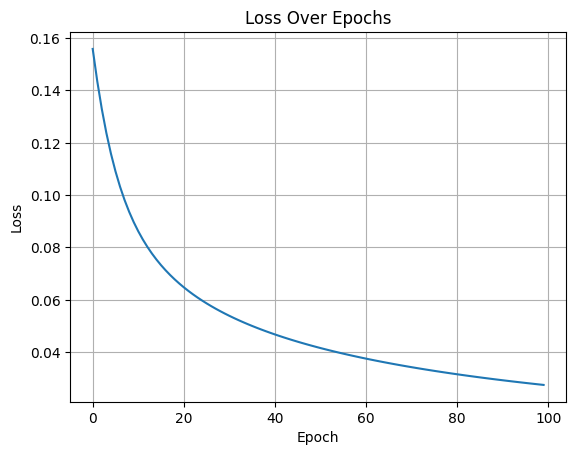

In [6]:
import matplotlib.pyplot as plt

# after training:
plt.plot(model.loss_history)
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [7]:
# ── 6. EVALUATE ───────────────────────────────────────────────────

train_acc = model.evaluate(X_train_scaled, Y_train)
test_acc  = model.evaluate(X_test_scaled,  Y_test)

print(f"\nTraining Accuracy = {round(train_acc * 100, 2)}%")
print(f"Testing  Accuracy = {round(test_acc  * 100, 2)}%")






Training Accuracy = 100.0%
Testing  Accuracy = 100.0%


In [8]:
# ── 7. PREDICT A NEW STUDENT ──────────────────────────────────────

new_student = np.array([[6, 7]], dtype=float)              # 6 study hrs, 7 sleep hrs
new_student_scaled = (new_student - mean) / std            # scale using training mean/std

prob = model.predict(new_student_scaled[0])

result = "PASS ✅" if prob >= 0.5 else "FAIL ❌"

print(f"\nNew student (6 hrs study, 7 hrs sleep):")
print(f"Probability = {round(float(prob)*100, 2)}%")
print(f"Prediction = {result}")


New student (6 hrs study, 7 hrs sleep):
Probability = 86.31%
Prediction = PASS ✅
